# Spatial · multi-field — pipeline demo template

The **spatial multi-field** template.  Every demo in this group follows the same three steps — **load → run → plot** — all driven by [`nb_support.py`](../nb_support.py):

1. **Load** a theory from `theories/<name>.theory.py` (the single source of truth — no inline model building).
2. **Run** it with one `nb.Config(...)`: the correlator order `k`, the loop order `max_ell`, the Dyson order, the grids, and every plotting option live there.
3. **Plot** with `nb.plot_cumulant`, which auto-dispatches to the form natural to this group.

This template ships with **`coupled_rd_2species_1d`**.  To demo a different spatial theory, set `THEORY` below to any multi-field spatial `theories/*.theory.py`.  Everything else is identical across all four group templates on purpose — common thematics for the demos.

## 1. Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import nb_support as nb
print('nb_support \u2192', nb.REPO_ROOT)

nb_support → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## 2. Choose the theory & configure the run

This is the only cell you edit.  `k` and `max_ell` are free (arbitrary correlator order and loop order); the plotting options (`show_orders`, `logy`, `figsize`, …) are adaptable.

In [2]:
THEORY = 'coupled_rd_2species_1d'   # any multi-field spatial theory

cfg = nb.Config(
    k=2,
    max_ell=1,      # 0 = tree, 1 = +1-loop, …

    spatial_grid=(-8.0, 8.0, 65),
    tau_max=0.0,

    # --- Dyson dressing (only when fields have UNEQUAL diffusion) ---
    # The theory default is equal D (no Dyson).  For Da ≠ Db set the
    # diffusion via `fundamental` and pick a Dyson order ≥ 0:
    # fundamental={'Da': 0.8, 'Db': 0.5},
    # dyson_order=1,

    show_orders='cumulative',
    logy=False,
)

In [3]:
model, mod = nb.load_theory(THEORY)
print('loaded :', model.get('name'))
print('fields :', nb.field_names(model),
      '| spatial_dim:', nb.spatial_dim(model),
      '| multi-field:', nb.is_multifield(model))
print('params :', [p['name'] for p in (model.get('parameters') or [])])

loaded : coupled-rd-2species-1d
fields : ['da', 'db'] | spatial_dim: 1 | multi-field: True
params : ['astar', 'bstar', 'mua', 'mub', 'Da', 'Db', 'g', 'h', 'ga', 'gb', 'Ta', 'Tb']


## 3. Run

In [4]:
res = nb.run(model, cfg, mod)
print(nb.summary(res))

theory : 'coupled-rd-2species-1d'
k      : 2    max_ell : 1
fields : ['da', 'db']   spatial_dim : 1
diagrams (live): 8


## 4. Plot

`show_orders` controls the per-loop-order overlay: `'cumulative'` (tree, tree+1-loop, …), `'incremental'` (each order alone), or `'total'` (the summed result only).

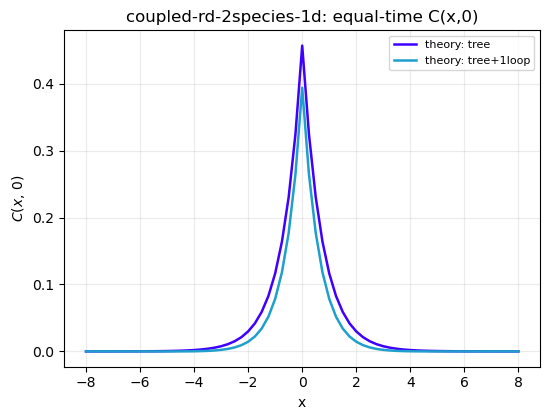

In [5]:
fig = nb.plot_cumulant(res, cfg, model)
plt.show()

### Arbitrary `k` (spatial)

For 3-point and higher spatial cumulants, replace `spatial_grid` with explicit evaluation events: `spatial_points` is an `(n_pts, k-1, 2)` array giving, for each of the `k-1` non-anchor legs, its `(x_j, τ_j)` offset from the anchor.  `nb.plot_cumulant` then draws the per-event bar chart automatically.  Example (`k=3`, two events):

```python
cfg = nb.Config(k=3, max_ell=0, spatial_points=[
    [[0.5, 0.0], [1.0, 0.0]],   # event 1: legs at x=0.5 and x=1.0
    [[1.0, 0.0], [2.0, 0.0]],   # event 2
])
```